In [1]:
# Goal of this .ipynb
# is to explore the dataset, 
# handle types and missing values, 
# scale the remaining data 
# and save the preprocessed data for further usage.

In [2]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import OneHotEncoder
import numpy as np
import seaborn as sns

In [3]:
dataset = pd.read_csv(filepath_or_buffer="./ml_sample_data_snapsoft.csv")
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore') 

In [4]:
# Possible outliers (carlength, cylindernumber, horsepower - 10 missing; mean vs 50% - seems ok)
dataset.describe()

,car_ID,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,compressionratio,horsepower,peakrpm,citympg,highwaympg,Price
count,245.000000,245.000000,235.000000,245.000000,245.000000,245.000000,235.000000,245.000000,245.000000,235.000000,245.000000,245.000000,245.000000,245.000000
mean,123.000000,98.550204,173.640426,65.838367,53.631429,2544.187755,4.365957,126.310204,10.113184,103.157447,5120.204082,25.236735,30.848980,13102.655784
std,70.869599,5.821847,11.967236,2.052447,2.465772,502.330860,1.038835,40.210431,3.988802,38.420034,472.447802,6.460558,6.773082,7803.824961
min,1.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,2.000000,61.000000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,62.000000,94.500000,166.300000,64.200000,51.600000,2169.000000,4.000000,98.000000,8.500000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,123.000000,96.600000,173.000000,65.400000,53.900000,2410.000000,4.000000,120.000000,9.000000,95.000000,5200.000000,24.000000,30.000000,10080.000000
75%,184.000000,101.200000,180.200000,66.500000,55.500000,2912.000000,4.000000,141.000000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,245.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,12.000000,326.000000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [5]:
# Review dataset
features = dataset.columns
data_types = dataset.dtypes
dataset_info = dataset.info()
print(dataset.isnull().sum())
print(dataset.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 245 entries, 0 to 244
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_ID             245 non-null    int64  
 1   CarName            235 non-null    str    
 2   ownername          245 non-null    str    
 3   owneremail         245 non-null    str    
 4   dealershipaddress  245 non-null    str    
 5   saledate           245 non-null    str    
 6   iban               245 non-null    str    
 7   fueltype           235 non-null    str    
 8   aspiration         245 non-null    str    
 9   doornumber         245 non-null    str    
 10  carbody            235 non-null    str    
 11  drivewheel         245 non-null    str    
 12  enginelocation     235 non-null    str    
 13  wheelbase          245 non-null    float64
 14  color              245 non-null    str    
 15  carlength          235 non-null    float64
 16  carwidth           245 non-null    fl

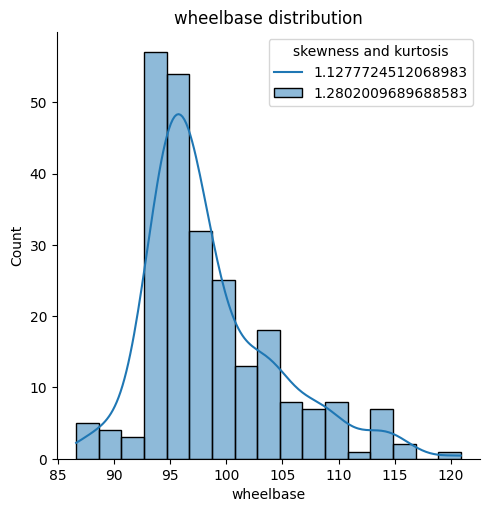

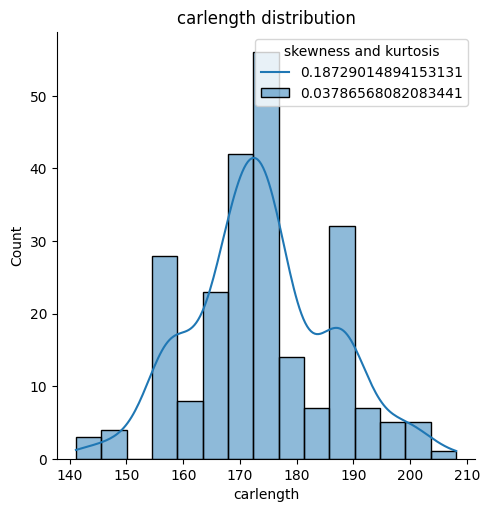

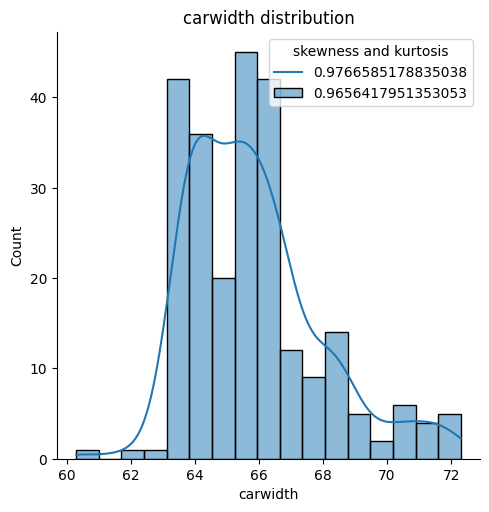

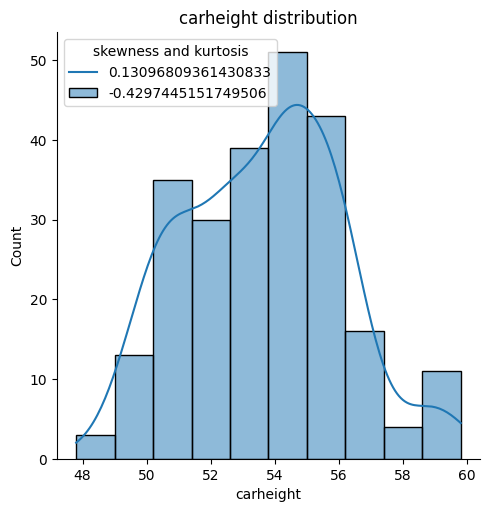

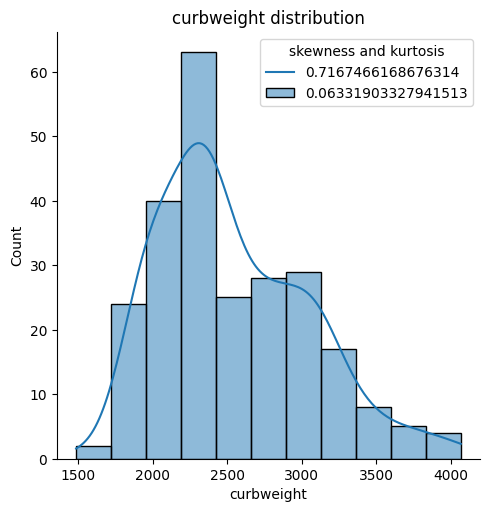

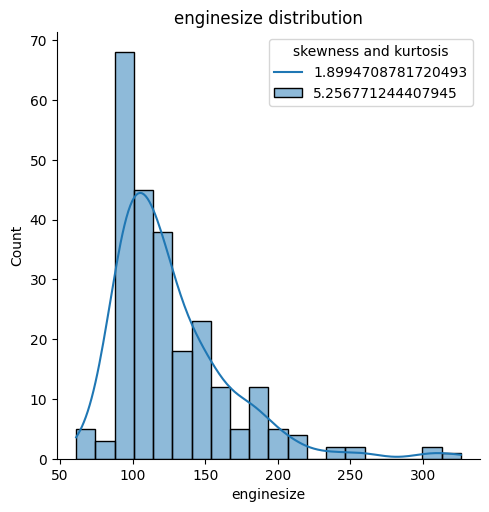

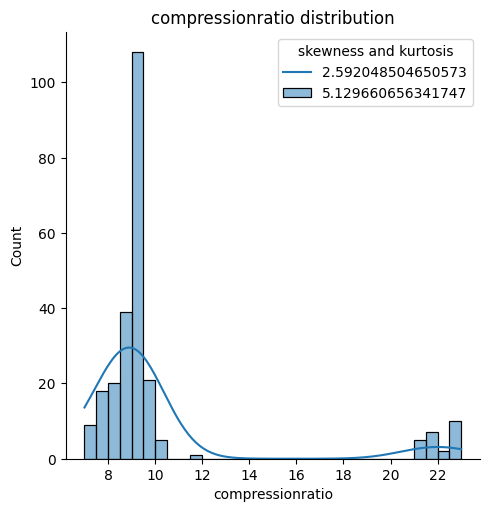

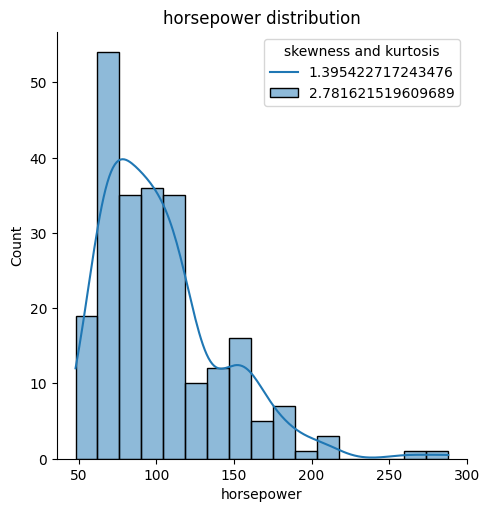

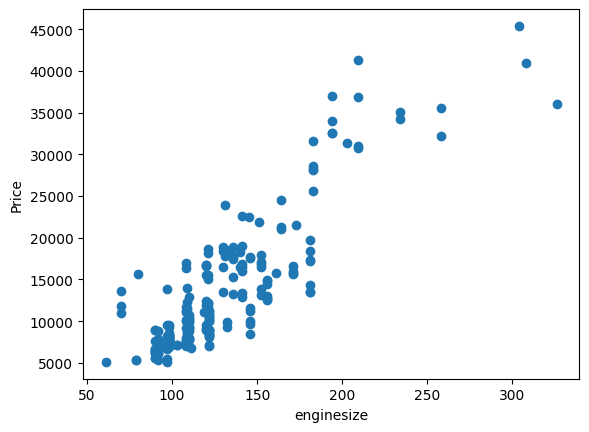

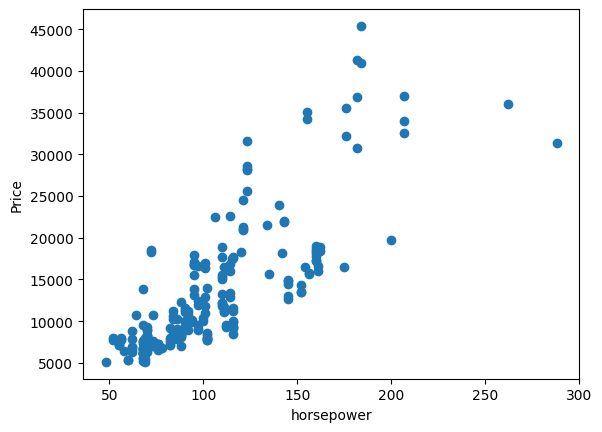

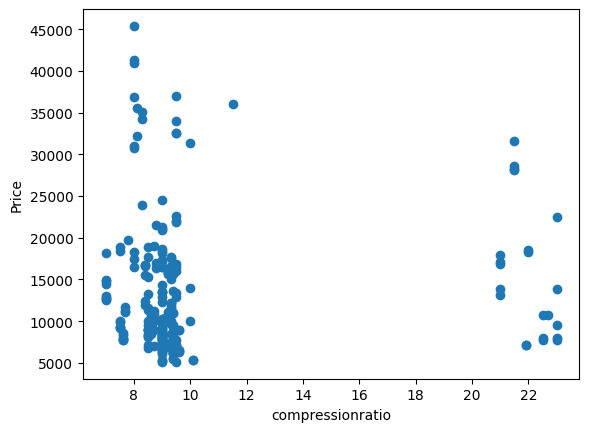

In [6]:
# Visualize the data
def plot_feature_hist(dataset, feature):
    # skewness tells us how normal distribution the data is. Skewness = 0 -> normal dist, Skewness < 0 more weight at right tail, Skewness > 0 more weight at left tail
    # kurtosis tells us how strongly affected our distribution by outliers. High kurtosis -> high likelihood to outliers
    sns.displot(dataset[feature],kde=True)
    plt.title(feature + " distribution")
    skewness=str(dataset[feature].skew())
    kurtosis=str(dataset[feature].kurt())
    plt.legend([skewness,kurtosis],title=("skewness and kurtosis"))
    plt.show()


def plot_two_features(dataset, feature_1, feature_2, number_of_points_to_plot=230):
    plt.xlabel(feature_1)
    plt.ylabel(feature_2)

    random_examples = dataset.sample(n=number_of_points_to_plot)
    plt.scatter(random_examples[feature_1], random_examples[feature_2])

    plt.show()

# Check data distribution for scaling
plot_feature_hist(dataset=dataset, feature="wheelbase")
plot_feature_hist(dataset=dataset, feature="carlength")
plot_feature_hist(dataset=dataset, feature="carwidth")
plot_feature_hist(dataset=dataset, feature="carheight")
plot_feature_hist(dataset=dataset, feature="curbweight")
plot_feature_hist(dataset=dataset, feature="enginesize")
plot_feature_hist(dataset=dataset, feature="compressionratio")
plot_feature_hist(dataset=dataset, feature="horsepower")

# Check linearity
plot_two_features(dataset=dataset, feature_1="enginesize", feature_2="Price")
plot_two_features(dataset=dataset, feature_1="horsepower", feature_2="Price")
plot_two_features(dataset=dataset, feature_1="compressionratio", feature_2="Price")

In [7]:
# Helper functions - Data imputation:
# Source: https://ansumanbhujabal.medium.com/machine-learning-basic-handling-missing-values-in-dataset-ca81914380ed
def fill_mean(dataset, feature_name):
    '''
    The mean is used to impute missing values when 
    dealing with continuous or numeric data, 
    such as age, income, or temperature.
    '''
    feature = list(dataset[feature_name])
    mean = round(np.nanmean(feature),1)
    for i, e in enumerate(feature):
        if pd.isna(e):
            feature[i] = mean

    dataset[feature_name] = feature

def fill_mode(dataset, feature_name):
    '''
    The mode is used for imputation when dealing with categorical data 
    or data with a limited set of distinct categories, 
    like car types, colors, or city names.
    '''
    feature = list(dataset[feature_name])
    frequencies = {}
    for e in set(feature):
        frequencies[e] = feature.count(e)
    max_element = max(frequencies, key=frequencies.get)
    for i, e in enumerate(feature):
        if pd.isna(e):
            feature[i] = max_element
    
    dataset[feature_name] = feature

def fill_median(dataset, feature_name):
    '''
    The median is a good choice for imputation when dealing with skewed data 
    or outliers in continuous or numeric data. 
    It’s less sensitive to extreme values than the mean.
    '''
    feature = list(dataset[feature_name])
    middle_idx = len(feature) // 2 - 1
    ordered_feature_middle_point = sorted(feature)[middle_idx]
    for i, e in enumerate(feature):
        if pd.isna(e):
            feature[i] = ordered_feature_middle_point

    dataset[feature_name] = feature

# Helper functions - Conversion

def category_to_num(dataset, feature_name):
    feature = list(dataset[feature_name])
    elements = set(feature)
    
    categories = {}
    for i, e in enumerate(elements):
        if not categories.get(e):
            categories[e] = float(i)

    for i, e in enumerate(feature):
        feature[i] = categories[e]
    
    dataset[feature_name] = feature

def remove_row_due_missing_element(dataset, feature_name):
    return dataset.dropna(subset=[feature_name])


def detect_outliers_and_clip(dataset, feature_name):
    feature = dataset[feature_name]
    Q1 = feature.quantile(0.25)
    Q3 = feature.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR 
    dataset[feature_name] = feature.clip(lower=lower_bound, upper=upper_bound)

def one_hot_encode_feature(dataset, feature_name):
    feature = dataset[[feature_name]]
    encoder.fit(feature)
    encoded_columns = encoder.get_feature_names_out() 
    encoded_features = encoder.transform(feature) 
    encoded_df = pd.DataFrame(encoded_features, columns=encoded_columns, index=dataset.index)
    dataset = pd.concat([dataset,encoded_df],axis=1).drop([feature_name], axis=1)
    return dataset


In [8]:
# Preprocess data
dataset.columns = (
    dataset.columns
    .str.strip()
    .str.lower()
)

# Selected features
# carname, saledate, fueltype, aspiration, doornumber, 
# carbody, drivewheel, enginelocation, wheelbase, color, carlength, 
# carwidth, carheight, curbweight, cylindernumber, enginesize, compressionratio, horsepower, peakrpm, citympg, highwaympg, price

# carname can be chunked to manufacturer only. 
# WARNING: INFORMATION LOSS HERE! NEED TO BE CAREFUL
to_separate_carname = dataset['carname'].str.split(' ',expand=True)
dataset['carname'] = to_separate_carname.iloc[0:, 0].to_list()

In [9]:
selected_features = ["carname" , "fueltype", "aspiration", "doornumber", "carbody", 
            "drivewheel", "enginelocation", "wheelbase", "color", "carlength", "carwidth", 
            "carheight", "curbweight", "cylindernumber", "enginesize", "compressionratio", 
            "horsepower", "peakrpm", "citympg", "highwaympg", "price"]

# DROP NOT SELECTED FEATURES
dataset = dataset[selected_features].copy()

# nulls/nans/missing values are the followings: carname, fueltype, carbody, enginelocation, carlength, cylindernumber, horsepower
# REMOVE MISSING ELEMENTS
dataset = remove_row_due_missing_element(dataset=dataset, feature_name='carname')
# detect and remove outliers
# I won't clip, because those outliers are meaningful: e.g. horsepower, compressionratio
#for feature in selected_features:
#    if dataset[feature].dtype == int or dataset[feature].dtype == float:
#        detect_outliers_and_clip(dataset, feature)

# DATA IMPUTATION
fill_mode(dataset=dataset, feature_name='fueltype')
fill_mode(dataset=dataset, feature_name='carbody')
fill_mode(dataset=dataset, feature_name='enginelocation')
fill_mean(dataset=dataset, feature_name="carlength")
fill_mean(dataset=dataset, feature_name="cylindernumber")
fill_mean(dataset=dataset, feature_name="horsepower")

# DATA CONVERSION

dataset = one_hot_encode_feature(dataset, "carname")
dataset = one_hot_encode_feature(dataset, "fueltype")
dataset = one_hot_encode_feature(dataset, "aspiration")
dataset = one_hot_encode_feature(dataset, "doornumber")
dataset = one_hot_encode_feature(dataset, "carbody")
dataset = one_hot_encode_feature(dataset, "drivewheel")
dataset = one_hot_encode_feature(dataset, "enginelocation")
dataset = one_hot_encode_feature(dataset, "color")

In [10]:
# Check our imputation results
dataset.describe()
dataset.isnull().sum()

wheelbase       0
carlength       0
carwidth        0
carheight       0
curbweight      0
               ..
color_purple    0
color_silver    0
color_teal      0
color_white     0
color_yellow    0
Length: 72, dtype: int64

In [11]:
# Save new train data
dataset.to_csv("./train.csv", index=False)